In [1]:
import pandas as pd
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, norm

In [2]:
path = "../data/milliquas.txt"
rfc_path = "/home/zagorulia/gamma/data/rfc_2025d_cat.txt"
classification_path = "/home/zagorulia/ml/classification_flux_density_ssl.csv"

In [3]:
def cs(a, b):
    return (a - 1, b)

colspecs = [
    cs(1, 11),     # RA (deg)
    cs(13, 23),    # DEC (deg)
    cs(26, 50),    # Name
    cs(52, 55),    # Type
    cs(57, 61),    # Rmag
    cs(63, 67),    # Bmag
    cs(69, 71),    # Comment
    cs(73, 73),    # R PSF
    cs(75, 75),    # B PSF
    cs(77, 82),    # Redshift
    cs(84, 89),    # Cite
    cs(91, 96),    # Zcite
    cs(98, 119),   # Xname
    cs(121, 142),  # Rname
    cs(144, 165),  # Lobe1
    cs(167, 188),  # Lobe2
]

names = [
    "ra_deg", "dec_deg", "name", "type",
    "rmag", "bmag", "comment",
    "r_psf", "b_psf",
    "z", "cite", "zcite",
    "xname", "rname", "lobe1", "lobe2",
]

milliquas = pd.read_fwf(
    path,
    colspecs=colspecs,
    names=names,
    comment="#",
    header=None
)
milliquas = milliquas[["ra_deg", "dec_deg", "z"]]
milliquas.head(2)

,ra_deg,dec_deg,z
0,0.000629,35.517844,0.845
1,0.000657,-20.074344,0.291


In [4]:
def cs(a, b):
    return (a - 1, b)

colspecs = [
    cs(1, 14),     # Name (RFC source designator)
    cs(17, 24),    # Comnam (Common name)

    cs(27, 28),    # RAh (hours)
    cs(30, 31),    # RAm (minutes)
    cs(33, 41),    # RAs (seconds)

    cs(43, 43),    # DE- (sign)
    cs(44, 45),    # DEd (degrees)
    cs(47, 48),    # DEm (arcmin)
    cs(50, 57),    # DEs (arcsec)

    cs(60, 65),    # eRA (mas)
    cs(67, 72),    # eDE (mas)
    cs(76, 81),    # Corr

    cs(83, 89),    # Nobs
    cs(91, 96),    # Nsca
    cs(98, 102),   # Nses

    cs(105, 110),  # FsS
    cs(112, 117),  # FmS
    cs(119, 124),  # FlS

    cs(127, 132),  # FsC
    cs(134, 139),  # FmC
    cs(141, 146),  # FlC

    cs(149, 154),  # FsX
    cs(156, 161),  # FmX
    cs(163, 168),  # FlX

    cs(171, 176),  # FsU
    cs(178, 183),  # FmU
    cs(185, 190),  # FlU

    cs(193, 198),  # FsK
    cs(200, 205),  # FmK
    cs(207, 212),  # FlK

    cs(215, 222),  # MeaEpo
]

names = [
    "Name", "Comnam",
    "RAh", "RAm", "RAs",
    "DE_sign", "DEd", "DEm", "DEs",
    "eRA_mas", "eDE_mas", "Corr",
    "Nobs", "Nsca", "Nses",
    "FsS_Jy", "FmS_Jy", "FlS_Jy",
    "FsC_Jy", "FmC_Jy", "FlC_Jy",
    "FsX_Jy", "FmX_Jy", "FlX_Jy",
    "FsU_Jy", "FmU_Jy", "FlU_Jy",
    "FsK_Jy", "FmK_Jy", "FlK_Jy",
    "MeaEpo_yr",
]
rfc = pd.read_fwf(
    rfc_path,
    colspecs=colspecs,
    names=names,
    comment="#",
    header=None
)
rfc.head(2)

,Name,Comnam,RAh,RAm,RAs,DE_sign,DEd,DEm,DEs,eRA_mas,...,FsX_Jy,FmX_Jy,FlX_Jy,FsU_Jy,FmU_Jy,FlU_Jy,FsK_Jy,FmK_Jy,FlK_Jy,MeaEpo_yr
0,RFC J0000-0022,2357-006,0,0,1.659840,-,0,22,10.02331,1.26,...,0.039,0.023,0.018,-9.99,-9.99,-9.99,-9.99,-9.99,-9.99,2022.703
1,RFC J0000-1352,2357-141,0,0,3.124501,-,13,52,0.75152,1.99,...,0.019,0.014,0.015,-9.99,-9.99,-9.99,-9.99,-9.99,-9.99,2015.997


In [5]:
rfc["ra_deg"] = rfc.apply(lambda r: (r["RAh"] + r["RAm"]/60 + r["RAs"]/3600) * 15, axis=1)
rfc["dec_deg"] = rfc.apply(lambda r: (r["DEd"] + r["DEm"]/60 + r["DEs"]/3600) * (-1 if r["DE_sign"] == "-" else 1), axis=1)
rfc["Jname"] = rfc["Name"].apply(lambda n: n.split()[1])
rfc = rfc[["Jname", "ra_deg", "dec_deg"]]
rfc.head(2)

,Jname,ra_deg,dec_deg
0,J0000-0022,0.006916,-0.369451
1,J0000-1352,0.013019,-13.866875


In [6]:
classification = pd.read_csv(classification_path, index_col=0)
classification["Jname"] = classification["file"].apply(lambda f: f.split("_")[0])
classification["band"] = classification["file"].apply(lambda f: f.split("_")[1])
classification = classification[classification.band == "X"]
classification.head(2)

,file,prob,pred,intensity,Jname,band
2,J1608-1625_X_2014_08_09_pus_map.fits,0.013989,0,0.067042,J1608-1625,X
3,J1608-1625_X_2017_08_05_pus_map.fits,0.006702,0,0.061133,J1608-1625,X


In [7]:
avg = (
    classification.groupby("Jname", as_index=False)
      .agg(
          prob_avg=("prob", "mean"),
          intensity_avg=("intensity", "mean"),
      )
)
avg.head(2)

,Jname,prob_avg,intensity_avg
0,J0000+0248,0.227787,0.040299
1,J0000+0307,0.528604,0.080211


In [8]:
res = (
    avg.merge(rfc[["Jname", "ra_deg", "dec_deg"]],
              on="Jname", how="left")
       .loc[:, ["Jname", "ra_deg", "dec_deg", "prob_avg", "intensity_avg"]]
)
res.head(2)

,Jname,ra_deg,dec_deg,prob_avg,intensity_avg
0,J0000+0248,0.080343,2.804081,0.227787,0.040299
1,J0000+0307,0.112594,3.121013,0.528604,0.080211


In [9]:
res = res.dropna()

In [10]:
import numpy as np
from scipy.spatial import cKDTree

tree = cKDTree(milliquas[["ra_deg", "dec_deg"]].to_numpy())
dist, idx = tree.query(res[["ra_deg", "dec_deg"]].to_numpy(), k=1)

res_with_z = res.copy()
res_with_z["z"] = milliquas["z"].to_numpy()[idx]
res_with_z["match_dist2"] = dist**2

res_with_z.head()

,Jname,ra_deg,dec_deg,prob_avg,intensity_avg,z,match_dist2
0,J0000+0248,0.080343,2.804081,0.227787,0.040299,1.763,1.737886e-02
1,J0000+0307,0.112594,3.121013,0.528604,0.080211,2.343,4.630781e-12
2,J0000+030B,0.184699,3.131723,0.125463,0.060468,2.343,5.314163e-03
3,J0000+0816,0.029297,8.279181,0.997868,0.027574,1.996,7.483035e-03
4,J0000+1139,0.081517,11.655758,0.290419,0.018031,1.868,1.264057e-03


In [17]:
res_with_z = res_with_z[res_with_z["match_dist2"] < 3]

In [23]:
cosmo = FlatLambdaCDM(H0=71 * u.km/u.s/u.Mpc, Om0=0.27)

def luminosity(s_jy, z, alpha = 0):
    Dl = cosmo.luminosity_distance(z)
    S  = (np.asarray(s_jy) * u.Jy).to(u.W / (u.m**2 * u.Hz))
    Lnu = (4 * np.pi * Dl**2 * S) / ((1 + z) ** (1 + alpha))
    return Lnu.to(u.W / u.Hz).value

In [24]:
res_with_z["luminosity"] = res_with_z.apply(lambda r: luminosity(r["intensity_avg"], r["z"]), axis=1)
d = res_with_z[res_with_z["luminosity"] > 0].copy()
d["log_lum"] = np.log10(d["luminosity"])

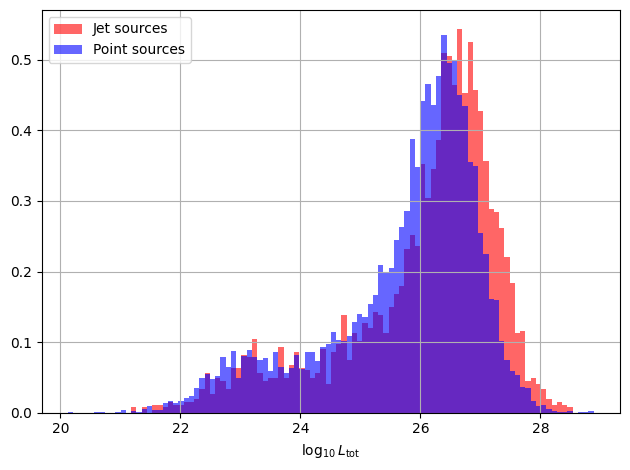

In [29]:
plt.figure()
points = d["prob_avg"] <= 0.25
jets = d["prob_avg"] >= 0.75
_, bins = np.histogram(d.loc[points, "log_lum"], bins=100)

plt.hist(d.loc[jets, "log_lum"], bins=bins, alpha=0.6, color='red', label="Jet sources", density=True)
plt.hist(d.loc[points, "log_lum"], bins=bins, alpha=0.6, color='blue', label="Point sources", density=True)
plt.xlabel(r"$\log_\text{10}L_\text{tot}$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
def dominance_stats(A, B):
    # one-sided MWU: H1: A > B
    U, p = mannwhitneyu(A, B, alternative="greater")

    n1, n2 = len(A), len(B)

    # Cliff's delta
    delta = (2*U)/(n1*n2) - 1

    # dominance probability
    P = (U)/(n1*n2)
    mean = n1*n2/2
    var  = n1*n2*(n1+n2+1)/12
    z = (U - mean) / np.sqrt(var)

    # log10(p) without underflow
    log10_p = np.log10(2) + (norm.logsf(abs(z)) / np.log(10))

    print("−log10(p) =", -log10_p)

    return {
        "p_value": p,
        "P(A > B)": P,
        "Cliffs_delta": delta
    }

In [28]:
dominance_stats(d.loc[points, "log_lum"], d.loc[jets, "log_lum"])

−log10(p) = 41.62126066162061


{'p_value': np.float64(1.0),
 'P(A > B)': np.float64(0.4157636059111288),
 'Cliffs_delta': np.float64(-0.16847278817774236)}